### **Streaming**

In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

llm_model = 'gpt-4o'
chat = ChatOpenAI(model = llm_model)

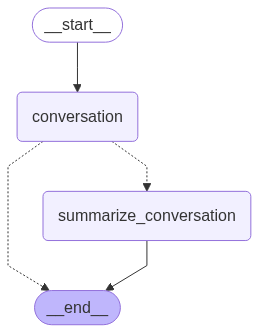

In [5]:
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langchain_core.runnables import RunnableConfig
from typing import Literal
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState

class State(MessagesState):
    summary: str

# Define the logic to call the model
def call_model(state: State, config: RunnableConfig):
    # Get summary if it exists
    summary = state.get('summary', '')

    # If there is summary, then we add it
    if summary:
        
        # Add summary to system message
        system_message = f'Summary of conversation earlier: {summary}'

        # Append summary to any newer messages
        messages = [SystemMessage(content = system_message)] + state['messages']
    
    else:
        messages = state['messages']
    
    response = chat.invoke(messages)
    return {'messages': response}

def summarize_conversation(state: State):
    # First, we get any existing summary
    summary = state.get('summary', '')

    # Create our summarization prompt 
    if summary:
        
        # A summary already exists
        summary_message = (
            f'This is summary of the conversation to date: {summary}\n\n'
            'Extend the summary by taking into account the new messages above:'
        )
        
    else:
        summary_message = 'Create a summary of the conversation above:'

    # Add prompt to our history
    messages = state['messages'] + [HumanMessage(content = summary_message)]
    response = chat.invoke(messages)
    
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id = m.id) for m in state['messages'][:-2]]
    return {'summary': response.content, 'messages': delete_messages}

import random
# Determine whether to end or summarize the conversation
def should_continue(state: State) -> Literal['summarize_conversation', END]:
    '''Return the next node to execute.'''
    
    messages = state['messages']
    
    # If there are more than six messages, then we summarize the conversation
    if len(messages) > 6:
        return 'summarize_conversation'
    
    # Otherwise we can just end
    return END

# Define a new graph
builder = StateGraph(State)
builder.add_node('conversation', call_model)
builder.add_node('summarize_conversation', summarize_conversation)

# Set the entrypoint as conversation
builder.add_edge(START, 'conversation')
builder.add_conditional_edges('conversation', should_continue)
builder.add_edge('summarize_conversation', END)

# Compile
memory = MemorySaver()
graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

#### **Streaming full state**
`.stream` and `.astream` are sync and async methods for streaming back results.

LangGraph supports a few different streaming modes for graph state:
- `values`: This streams the full state of the graph after each node is called.
- `updates`: This streams updates to the state of the graph after each node is called.

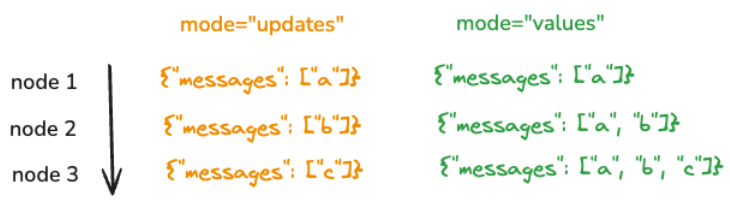

In [8]:
# Create a thread
config = {'configurable': {'thread_id': '1'}}

# Start conversation
for chunk in graph.stream({'messages': [HumanMessage(content = 'hi! I\'m Lance')]}, config, stream_mode = 'updates'):
    chunk['conversation']["messages"].pretty_print()

================================== Ai Message ==================================

Hi Lance! It’s great to meet you. What would you like to talk about today?


In [9]:
# Start conversation, again
config = {'configurable': {'thread_id': '2'}}

# Start conversation
input_message = HumanMessage(content = 'hi! I\'m Lance')
for event in graph.stream({'messages': [input_message]}, config, stream_mode = 'values'):
    for m in event['messages']:
        m.pretty_print()

================================ Human Message =================================

hi! I'm Lance
================================ Human Message =================================

hi! I'm Lance
================================== Ai Message ==================================

Hello, Lance! How can I assist you today?


#### **Streaming tokens**
We often want to stream more than graph state. In particular, with chat model calls it is common to stream the tokens as they are generated. We can do this using the .astream_events method, which streams back events as they happen inside nodes! 

Each event is a dict with a few keys:
- `event`: This is the type of event that is being emitted.
- `name`: This is the name of event.
- `data`: This is the data associated with the event.
- `metadata`: Containslanggraph_node, the node emitting the event.

In [ ]:
config = {'configurable': {'thread_id': '3'}}
input_message = HumanMessage(content = 'Tell me about the 49ers NFL team')

async for event in graph.astream_events({'messages': [input_message]}, config, version = 'v2'):
    print(f"Node: {event['metadata'].get('langgraph_node','')}. Type: {event['event']}. Name: {event['name']}")

Node: . Type: on_chain_start. Name: LangGraph
Node: conversation. Type: on_chain_start. Name: conversation
Node: conversation. Type: on_chat_model_start. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. Name: ChatOpenAI
Node: conversation. Type: on_chat_model_stream. N

In [12]:
config = {'configurable': {'thread_id': '4'}}
node_to_stream = 'conversation'

async for event in graph.astream_events({'messages': [input_message]}, config, version = 'v2'):
    # Get chat model tokens from a particular node 
    if event['event'] == 'on_chat_model_stream' and event['metadata'].get('langgraph_node', '') == node_to_stream:
        print(event['data'])

{'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content='The', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content=' San', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content=' Francisco', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content=' ', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content='49', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content='ers', additional_kwargs={}, response_metadata={}, id='run--4441e290-f0d6-4324-a36f-7b21ccd9b416')}
{'chunk': AIMessageChunk(content=' are', additional_kwargs={}, resp

In [13]:
config = {'configurable': {'thread_id': '5'}}

async for event in graph.astream_events({'messages': [input_message]}, config, version = 'v2'):
    # Get chat model tokens from a particular node 
    if event['event'] == 'on_chat_model_stream' and event['metadata'].get('langgraph_node', '') == node_to_stream:
        data = event['data']
        print(data['chunk'].content, end = '!')

!The! San! Francisco! !49!ers! are! a! professional! American! football! team! based! in! the! San! Francisco! Bay! Area!.! They! compete! in! the! National! Football! League! (!NFL!)! as! a! member! club! of! the! league!'s! National! Football! Conference! (!N!FC!)! West! division!.! The! team! was! founded! in! !194!6! as! a! charter! member! of! the! All!-Amer!ica! Football! Conference! (!AA!FC!)! and! joined! the! NFL! in! !194!9! when! the! leagues! merged!.

!###! Key! Historical! Highlights!:

!-! **!Super! Bowl! Success!**!:! The! !49!ers! have! won! five! Super! Bowl! championships!,! with! victories! in! Super! Bowl! XVI!,! XIX!,! XX!III!,! XX!IV!,! and! XX!IX!.! These! wins!,! primarily! during! the! !198!0!s! and! early! !199!0!s!,! have! cement!ed! the! team's! legacy! as! one! of! the! NFL!'s! stor!ied! franchises!.

!-! **!Icon!ic! Players!**!:! The! team! has! been! home! to! numerous! Hall! of! Fam!ers!,! including! Joe! Montana!,! Jerry! Rice!,! Steve! Young!,! Ronnie

#### **Streaming with LangGraph API**

In [15]:
if 'google.colab' in str(get_ipython()):
    raise Exception('Unfortunately LangGraph Studio is currently not supported on Google Colab')

In [17]:
from langgraph_sdk import get_client

# This is the URL of the local development server
URL = 'http://127.0.0.1:2024'
client = get_client(url=URL)

# Search all hosted graphs
assistants = await client.assistants.search()

In [ ]:
# Create a new thread
thread = await client.threads.create()
# Input message
input_message = HumanMessage(content = 'Multiply 2 and 3')
async for event in client.runs.stream(
    thread['thread_id'], 
    assistant_id = 'agent', 
    input = {'messages': [input_message]},
    stream_mode = 'values'
):
    print(event)

StreamPart(event='metadata', data={'run_id': '1f037a66-8394-6eea-8cec-3d5ff906ec6a', 'attempt': 1})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '8e39a4c2-b62c-47cb-9379-3cf19ee10eb1', 'example': False}]})
StreamPart(event='values', data={'messages': [{'content': 'Multiply 2 and 3', 'additional_kwargs': {}, 'response_metadata': {}, 'type': 'human', 'name': None, 'id': '8e39a4c2-b62c-47cb-9379-3cf19ee10eb1', 'example': False}, {'content': '', 'additional_kwargs': {'tool_calls': [{'id': 'call_wfYlOOqoCxTrxy5qBv7VHRvt', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, 'response_metadata': {'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_

The streamed objects have:
- `event`: Type
- `data`: State

In [19]:
from langchain_core.messages import convert_to_messages
thread = await client.threads.create()
input_message = HumanMessage(content = 'Multiply 2 and 3')
async for event in client.runs.stream(thread['thread_id'], assistant_id = 'agent', input = {'messages': [input_message]}, stream_mode = 'values'):
    messages = event.data.get('messages', None)
    if messages:
        print(convert_to_messages(messages)[-1])
    print('='*25)

content='Multiply 2 and 3' additional_kwargs={} response_metadata={} id='5679148c-b251-4b1b-b424-bb54d44cef06'
content='' additional_kwargs={'invalid_tool_calls': [], 'usage_metadata': {'input_tokens': 134, 'output_tokens': 17, 'total_tokens': 151, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}, 'tool_calls': [{'id': 'call_x5sHE8QQg5WGlLN9z6c1WRoG', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 134, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BaH1TQVZ84rKjFXqmu5ZQmDWoAnNU', 'service_tier': 'default', 'finish_reason': 'tool_cal

There are some new streaming mode that are only supported via the API. For example, we can use `messages` mode to better handle the above case! This mode currently assumes that you have a `messages` key in your graph, which is a list of messages. All events emitted using messages mode have two attributes:
- `event`: This is the name of the event
- `data`: This is data associated with the event

In [21]:
# Create a new thread
thread = await client.threads.create()
# Input message
input_message = HumanMessage(content = 'Multiply 2 and 3')
async for event in client.runs.stream(
    thread['thread_id'], 
    assistant_id = 'agent', 
    input = {'messages': [input_message]},
    stream_mode = 'messages'
):
    print(event.event)

metadata
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/metadata
messages/complete
messages/metadata
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial
messages/partial


- `metadata`: metadata about the run
- `messages/complete`: fully formed message
- `messages/partial`: chat model tokens

In [22]:
thread = await client.threads.create()
input_message = HumanMessage(content='Multiply 2 and 3')

def format_tool_calls(tool_calls):
    '''
    Format a list of tool calls into a readable string.

    Args:
        tool_calls (list): A list of dictionaries, each representing a tool call.
            Each dictionary should have 'id', 'name', and 'args' keys.

    Returns:
        str: A formatted string of tool calls, or 'No tool calls' if the list is empty.
    '''

    if tool_calls:
        formatted_calls = []
        for call in tool_calls:
            formatted_calls.append(
                f'Tool Call ID: {call["id"]}, Function: {call["name"]}, Arguments: {call["args"]}'
            )
        return '\n'.join(formatted_calls)
    return 'No tool calls'

async for event in client.runs.stream(
    thread['thread_id'],
    assistant_id='agent',
    input={'messages': [input_message]},
    stream_mode='messages',
):
    # Handle metadata events
    if event.event == 'metadata':
        print(f'Metadata: Run ID - {event.data["run_id"]}')
        print('-' * 50)
    
    # Handle partial message events
    elif event.event == 'messages/partial':
        for data_item in event.data:
            # Process user messages
            if 'role' in data_item and data_item['role'] == 'user':
                print(f'Human: {data_item["content"]}')
            else:
                # Extract relevant data from the event
                tool_calls = data_item.get('tool_calls', [])
                invalid_tool_calls = data_item.get('invalid_tool_calls', [])
                content = data_item.get('content', '')
                response_metadata = data_item.get('response_metadata', {})

                if content:
                    print(f'AI: {content}')

                if tool_calls:
                    print('Tool Calls:')
                    print(format_tool_calls(tool_calls))

                if invalid_tool_calls:
                    print('Invalid Tool Calls:')
                    print(format_tool_calls(invalid_tool_calls))

                if response_metadata:
                    finish_reason = response_metadata.get('finish_reason', 'N/A')
                    print(f'Response Metadata: Finish Reason - {finish_reason}')
                    
        print('-' * 50)


Metadata: Run ID - 1f037a75-58ca-6f94-84f1-17f8fa0b040d
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: call_1lZWaNYuK7hgrnAE2CQCqtJw, Function: multiply, Arguments: {'a': 2}
--------------------------------------------------
Tool Calls:
Tool Call ID: cal